<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/%20Detailed%20Error%20/%20Failure%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# DETAILED ERROR / FAILURE ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import os
import json

print("Detailed Error / Failure Analysis")
print("=================================")
print("Notebook started successfully.")

Detailed Error / Failure Analysis
Notebook started successfully.


In [2]:
# ==========================================
# STEP 2: UPLOAD DATASET ZIP
# ==========================================

from google.colab import files

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("Uploaded file:", zip_file)

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip
Uploaded file: Underwater-Image-Data-set-main.zip


In [3]:
# ==========================================
# STEP 3: EXTRACT DATASET
# ==========================================

import zipfile
import os

extract_folder = "/content/error_analysis_data"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP extracted successfully.")
print("Extracted to:", extract_folder)

ZIP extracted successfully.
Extracted to: /content/error_analysis_data


In [4]:
# ==========================================
# STEP 4: FIND TRAINING LOG CSV FILES
# ==========================================

import glob
import os

csv_files = glob.glob(
    "/content/error_analysis_data/**/*.csv",
    recursive=True
)

print("CSV files found:", len(csv_files))

for f in csv_files:
    print("-", os.path.basename(f))

CSV files found: 8
- training_log 2.csv
- training_log 4.csv
- training_log 6.csv
- training_log 8.csv
- training_log 1.csv
- training_log 5.csv
- training_log 7.csv
- training_log 3.csv


In [5]:
# ==========================================
# STEP 5: COMBINE TRAINING LOGS
# ==========================================

all_logs = []

for file in csv_files:
    df_temp = pd.read_csv(file)
    df_temp["source_file"] = os.path.basename(file)
    all_logs.append(df_temp)

combined_df = pd.concat(
    all_logs,
    ignore_index=True
)

print("Combined dataset shape:", combined_df.shape)

print("\nColumns:")
print(combined_df.columns.tolist())

print("\nFirst 5 rows:")
display(combined_df.head())

Combined dataset shape: (24915, 6)

Columns:
['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']

First 5 rows:


,epoch,step,gen_total,disc_loss,time_s,source_file
0,1,30,39.782654,0.618856,130.054897,training_log 2.csv
1,1,31,39.431751,0.594878,135.857588,training_log 2.csv
2,1,32,31.144588,0.691624,140.604372,training_log 2.csv
3,1,33,57.094162,0.559530,145.975339,training_log 2.csv
4,1,34,46.443527,0.533368,149.309059,training_log 2.csv


In [6]:
# ==========================================
# STEP 6: FINAL TCN CONFIGURATION
# ==========================================

FEATURES = ["epoch", "step", "disc_loss", "time_s"]
TARGET = "gen_total"

SEQUENCE_LENGTH = 10

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

HIDDEN_CHANNELS = 64
DROPOUT = 0.0
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
EPOCHS = 15

RANDOM_SEED = 42

print("FINAL TCN CONFIGURATION")
print("=======================")
print("Features:", FEATURES)
print("Target:", TARGET)
print("Sequence length:", SEQUENCE_LENGTH)
print("Split: 70% Train / 15% Validation / 15% Test")
print("Hidden channels:", HIDDEN_CHANNELS)
print("Dropout:", DROPOUT)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

FINAL TCN CONFIGURATION
Features: ['epoch', 'step', 'disc_loss', 'time_s']
Target: gen_total
Sequence length: 10
Split: 70% Train / 15% Validation / 15% Test
Hidden channels: 64
Dropout: 0.0
Learning rate: 0.0005
Batch size: 32
Epochs: 15


In [7]:
# ==========================================
# STEP 7: CREATE SEQUENCES
# ==========================================

X_data = combined_df[FEATURES].values
y_data = combined_df[TARGET].values

X_sequences = []
y_sequences = []

for i in range(len(X_data) - SEQUENCE_LENGTH):
    X_sequences.append(
        X_data[i:i + SEQUENCE_LENGTH]
    )
    y_sequences.append(
        y_data[i + SEQUENCE_LENGTH]
    )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Sequences created successfully.")
print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

Sequences created successfully.
X shape: (24905, 10, 4)
y shape: (24905,)


In [8]:
# ==========================================
# STEP 8: TIME-ORDERED TRAIN / VAL / TEST SPLIT
# ==========================================

total_samples = len(X_sequences)

train_end = int(total_samples * TRAIN_RATIO)
validation_end = int(
    total_samples * (TRAIN_RATIO + VALIDATION_RATIO)
)

X_train = X_sequences[:train_end]
y_train = y_sequences[:train_end]

X_val = X_sequences[train_end:validation_end]
y_val = y_sequences[train_end:validation_end]

X_test = X_sequences[validation_end:]
y_test = y_sequences[validation_end:]

print("TIME-ORDERED SPLIT")
print("==================")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nPercentages:")
print(f"Train: {len(X_train)/total_samples*100:.2f}%")
print(f"Validation: {len(X_val)/total_samples*100:.2f}%")
print(f"Test: {len(X_test)/total_samples*100:.2f}%")

TIME-ORDERED SPLIT
Training samples: 17433
Validation samples: 3736
Test samples: 3736

Percentages:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


In [9]:
# ==========================================
# STEP 9: TRAINING-ONLY NORMALIZATION
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data
scaler.fit(
    X_train.reshape(-1, X_train.shape[-1])
)

# Transform all sets using the training-fitted scaler
X_train_scaled = scaler.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

print("Normalization completed successfully.")
print("Scaler fitted only on training data.")

print("\nShapes:")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Normalization completed successfully.
Scaler fitted only on training data.

Shapes:
Train: (17433, 10, 4)
Validation: (3736, 10, 4)
Test: (3736, 10, 4)


In [10]:
# ==========================================
# STEP 10: BUILD FINAL TCN
# ==========================================

import torch
import torch.nn as nn

class TCNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv1d(
                input_size, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 64,
                kernel_size=3,
                padding=2,
                dilation=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 32,
                kernel_size=3,
                padding=4,
                dilation=4
            ),
            nn.ReLU()
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.network(x)
        x = x[:, :, -1]
        return self.fc(x)


model = TCNModel(len(FEATURES))

print("Final TCN created successfully.")
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Final TCN created successfully.
Trainable parameters: 19393


In [11]:
# ==========================================
# STEP 11: TRAIN FINAL TCN
# ==========================================

from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train, dtype=torch.float32
).view(-1, 1)

X_val_tensor = torch.tensor(
    X_val_scaled, dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val, dtype=torch.float32
).view(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

model = TCNModel(len(FEATURES)).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
best_model_state = None

print("Training final TCN...")
print("Device:", device)

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()
        optimizer.step()

        train_loss += (
            loss.item() * len(X_batch)
        )

    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            val_loss += (
                loss.item() * len(X_batch)
            )

    val_loss /= len(val_dataset)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

model.load_state_dict(best_model_state)

print("\nTraining completed.")
print("Best validation loss:", best_val_loss)

Training final TCN...
Device: cpu
Epoch 01/15 | Train Loss: 108.261068 | Val Loss: 64.762450
Epoch 02/15 | Train Loss: 37.719317 | Val Loss: 54.811555
Epoch 03/15 | Train Loss: 34.863273 | Val Loss: 50.143147
Epoch 04/15 | Train Loss: 33.484216 | Val Loss: 47.608835
Epoch 05/15 | Train Loss: 32.308475 | Val Loss: 46.427215
Epoch 06/15 | Train Loss: 31.635104 | Val Loss: 45.535642
Epoch 07/15 | Train Loss: 31.017225 | Val Loss: 44.307914
Epoch 08/15 | Train Loss: 30.663433 | Val Loss: 44.414390
Epoch 09/15 | Train Loss: 30.543711 | Val Loss: 43.990832
Epoch 10/15 | Train Loss: 30.234098 | Val Loss: 43.827132
Epoch 11/15 | Train Loss: 30.022545 | Val Loss: 43.713758
Epoch 12/15 | Train Loss: 29.797901 | Val Loss: 43.546292
Epoch 13/15 | Train Loss: 29.851989 | Val Loss: 43.909796
Epoch 14/15 | Train Loss: 29.922578 | Val Loss: 44.966079
Epoch 15/15 | Train Loss: 29.981469 | Val Loss: 45.472109

Training completed.
Best validation loss: 43.5462921314117


In [12]:
# ==========================================
# STEP 12: TEST PREDICTIONS & INDIVIDUAL ERRORS
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)

with torch.no_grad():
    predictions = model(X_test_tensor)

y_pred = predictions.cpu().numpy().flatten()
y_actual = y_test.flatten()

# Create detailed error table
error_df = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_pred
})

error_df["Error"] = (
    error_df["Predicted"] - error_df["Actual"]
)

error_df["Absolute_Error"] = (
    np.abs(error_df["Error"])
)

error_df["Percentage_Error"] = np.where(
    error_df["Actual"] != 0,
    error_df["Absolute_Error"]
    / np.abs(error_df["Actual"]) * 100,
    np.nan
)

print("Test predictions generated successfully.")
print("Number of test predictions:", len(error_df))

print("\nFirst 10 predictions:")
display(error_df.head(10).round(6))

Test predictions generated successfully.
Number of test predictions: 3736

First 10 predictions:


,Actual,Predicted,Error,Absolute_Error,Percentage_Error
0,22.053410,19.172392,-2.881018,2.881018,13.063820
1,23.947186,19.159796,-4.787390,4.787390,19.991451
2,24.386560,19.123465,-5.263096,5.263096,21.581952
3,25.162313,19.146477,-6.015837,6.015837,23.908122
4,21.503168,19.128578,-2.374590,2.374590,11.042977
5,24.311855,19.101513,-5.210342,5.210342,21.431283
6,23.880564,19.175295,-4.705269,4.705269,19.703341
7,21.200558,19.357164,-1.843393,1.843393,8.695023
8,17.349014,19.611654,2.262640,2.262640,13.041894
9,25.124681,20.047010,-5.077671,5.077671,20.209892


In [13]:
# ==========================================
# STEP 13: WORST PREDICTIONS
# ==========================================

worst_predictions = error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(20).copy()

print("TOP 20 WORST PREDICTIONS")
print("========================")

display(
    worst_predictions.round(6)
)

# Save for reporting
worst_predictions.to_csv(
    "/content/worst_predictions.csv",
    index=False
)

print("\nWorst-prediction table saved as:")
print("/content/worst_predictions.csv")

TOP 20 WORST PREDICTIONS


,Actual,Predicted,Error,Absolute_Error,Percentage_Error
3491,24.754225,9.116291,-15.637934,15.637934,63.172787
3735,22.243809,8.999892,-13.243917,13.243917,59.539788
3583,16.444281,3.249277,-13.195004,13.195004,80.240687
3221,17.810534,5.186536,-12.623998,12.623998,70.879391
3345,20.322777,8.386772,-11.936005,11.936005,58.732154
2994,19.913315,8.002224,-11.911091,11.911091,59.814707
3008,20.543194,9.039268,-11.503925,11.503925,55.998719
2705,20.818750,9.457362,-11.361388,11.361388,54.572863
2270,20.971518,9.686424,-11.285093,11.285093,53.811524
3579,19.278000,8.057610,-11.220390,11.220390,58.203083



Worst-prediction table saved as:
/content/worst_predictions.csv


In [14]:
# ==========================================
# STEP 14: ERROR DISTRIBUTION ANALYSIS
# ==========================================

mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

r2 = r2_score(y_actual, y_pred)

non_zero = y_actual != 0

mape = np.mean(
    np.abs(
        (y_actual[non_zero] - y_pred[non_zero])
        / y_actual[non_zero]
    )
) * 100

percentile_95 = np.percentile(
    error_df["Absolute_Error"],
    95
)

max_error = error_df["Absolute_Error"].max()
mean_error = error_df["Absolute_Error"].mean()

print("ERROR DISTRIBUTION")
print("==================")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.6f}%")
print(f"R²: {r2:.6f}")
print(f"Mean absolute error: {mean_error:.6f}")
print(f"95th percentile absolute error: {percentile_95:.6f}")
print(f"Maximum absolute error: {max_error:.6f}")

ERROR DISTRIBUTION
MAE: 2.412714
RMSE: 3.164585
MAPE: 18.652487%
R²: 0.132594
Mean absolute error: 2.412714
95th percentile absolute error: 6.309841
Maximum absolute error: 15.637934


In [15]:
# ==========================================
# STEP 15: RECURRING ERRORS BY SOURCE FILE
# ==========================================

# Add source information to test samples
test_start = validation_end

test_source = combined_df.iloc[
    test_start + SEQUENCE_LENGTH:
    test_start + SEQUENCE_LENGTH + len(error_df)
]["source_file"].values

error_df["source_file"] = test_source

source_error_summary = (
    error_df
    .groupby("source_file")
    .agg(
        Samples=("Absolute_Error", "count"),
        Mean_Absolute_Error=("Absolute_Error", "mean"),
        Maximum_Error=("Absolute_Error", "max"),
        Median_Absolute_Error=("Absolute_Error", "median")
    )
    .sort_values(
        "Mean_Absolute_Error",
        ascending=False
    )
    .reset_index()
)

print("ERRORS BY SOURCE / TRAINING RUN")
print("===============================")

display(
    source_error_summary.round(6)
)

source_error_summary.to_csv(
    "/content/source_error_summary.csv",
    index=False
)

print("\nSaved:")
print("/content/source_error_summary.csv")

ERRORS BY SOURCE / TRAINING RUN


,source_file,Samples,Mean_Absolute_Error,Maximum_Error,Median_Absolute_Error
0,training_log 3.csv,3736,2.412714,15.637934,1.907706



Saved:
/content/source_error_summary.csv


In [16]:
# ==========================================
# STEP 16: ERROR ANALYSIS BY TARGET RANGE
# ==========================================

# Create target-value ranges using test-set quartiles
q1 = error_df["Actual"].quantile(0.25)
q2 = error_df["Actual"].quantile(0.50)
q3 = error_df["Actual"].quantile(0.75)

def target_range(value):
    if value <= q1:
        return "Low"
    elif value <= q2:
        return "Medium-Low"
    elif value <= q3:
        return "Medium-High"
    else:
        return "High"

error_df["Target_Range"] = error_df["Actual"].apply(
    target_range
)

range_error_summary = (
    error_df
    .groupby("Target_Range")
    .agg(
        Samples=("Absolute_Error", "count"),
        Mean_Absolute_Error=("Absolute_Error", "mean"),
        Maximum_Error=("Absolute_Error", "max"),
        Mean_Percentage_Error=("Percentage_Error", "mean")
    )
    .reindex([
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ])
    .reset_index()
)

print("ERRORS BY TARGET-VALUE RANGE")
print("============================")

display(
    range_error_summary.round(6)
)

range_error_summary.to_csv(
    "/content/target_range_error_summary.csv",
    index=False
)

print("\nSaved:")
print("/content/target_range_error_summary.csv")

ERRORS BY TARGET-VALUE RANGE


,Target_Range,Samples,Mean_Absolute_Error,Maximum_Error,Mean_Percentage_Error
0,Low,934,1.386886,8.040089,16.262446
1,Medium-Low,934,1.927684,7.723449,16.993663
2,Medium-High,934,2.795174,9.889794,20.710686
3,High,934,3.541113,15.637934,20.643153



Saved:
/content/target_range_error_summary.csv


In [17]:
# ==========================================
# STEP 17: FEATURE IMPORTANCE
# ==========================================

from sklearn.metrics import mean_absolute_error

# Baseline test MAE
baseline_mae = mean_absolute_error(y_actual, y_pred)

feature_importance = []

for feature_index, feature_name in enumerate(FEATURES):

    X_permuted = X_test_scaled.copy()

    # Keep the time/sequence structure, but shuffle
    # the selected feature across test sequences
    rng = np.random.default_rng(RANDOM_SEED)

    shuffled_values = X_permuted[:, :, feature_index].copy()
    rng.shuffle(shuffled_values)

    X_permuted[:, :, feature_index] = shuffled_values

    X_perm_tensor = torch.tensor(
        X_permuted,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        perm_predictions = model(X_perm_tensor)

    perm_predictions = (
        perm_predictions
        .cpu()
        .numpy()
        .flatten()
    )

    perm_mae = mean_absolute_error(
        y_actual,
        perm_predictions
    )

    importance = perm_mae - baseline_mae

    feature_importance.append({
        "Feature": feature_name,
        "Baseline_MAE": baseline_mae,
        "Permuted_MAE": perm_mae,
        "MAE_Increase": importance
    })

feature_importance_df = pd.DataFrame(
    feature_importance
).sort_values(
    "MAE_Increase",
    ascending=False
)

print("FEATURE IMPORTANCE")
print("==================")
print(
    "Larger MAE increase = greater influence on model predictions."
)

display(
    feature_importance_df.round(6)
)

feature_importance_df.to_csv(
    "/content/feature_importance.csv",
    index=False
)

print("\nSaved:")
print("/content/feature_importance.csv")

FEATURE IMPORTANCE
Larger MAE increase = greater influence on model predictions.


,Feature,Baseline_MAE,Permuted_MAE,MAE_Increase
0,epoch,2.412714,3.704946,1.292232
1,step,2.412714,2.487828,0.075114
2,disc_loss,2.412714,2.403780,-0.008934
3,time_s,2.412714,2.398464,-0.014251



Saved:
/content/feature_importance.csv


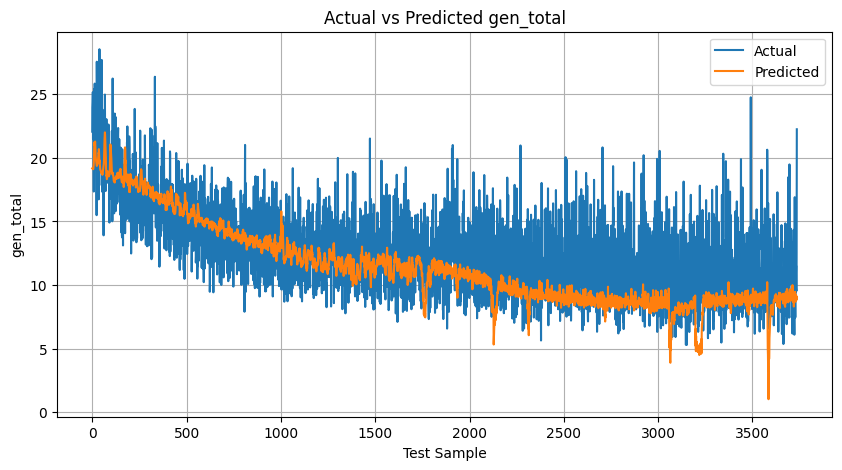

In [18]:
# ==========================================
# STEP 18: ACTUAL VS PREDICTED
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("gen_total")
plt.title("Actual vs Predicted gen_total")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# ==========================================
# STEP 19: INDIVIDUAL WORST-CASE INSPECTION
# ==========================================

worst_cases = error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10).copy()

worst_cases.insert(
    0,
    "Rank",
    range(1, len(worst_cases) + 1)
)

print("TOP 10 WORST PREDICTIONS")
print("========================")

display(
    worst_cases[
        [
            "Rank",
            "Actual",
            "Predicted",
            "Error",
            "Absolute_Error",
            "Percentage_Error",
            "Target_Range",
            "source_file"
        ]
    ].round(6)
)

TOP 10 WORST PREDICTIONS


,Rank,Actual,Predicted,Error,Absolute_Error,Percentage_Error,Target_Range,source_file
3491,1,24.754225,9.116291,-15.637934,15.637934,63.172787,High,training_log 3.csv
3735,2,22.243809,8.999892,-13.243917,13.243917,59.539788,High,training_log 3.csv
3583,3,16.444281,3.249277,-13.195004,13.195004,80.240687,High,training_log 3.csv
3221,4,17.810534,5.186536,-12.623998,12.623998,70.879391,High,training_log 3.csv
3345,5,20.322777,8.386772,-11.936005,11.936005,58.732154,High,training_log 3.csv
2994,6,19.913315,8.002224,-11.911091,11.911091,59.814707,High,training_log 3.csv
3008,7,20.543194,9.039268,-11.503925,11.503925,55.998719,High,training_log 3.csv
2705,8,20.818750,9.457362,-11.361388,11.361388,54.572863,High,training_log 3.csv
2270,9,20.971518,9.686424,-11.285093,11.285093,53.811524,High,training_log 3.csv
3579,10,19.278000,8.057610,-11.220390,11.220390,58.203083,High,training_log 3.csv


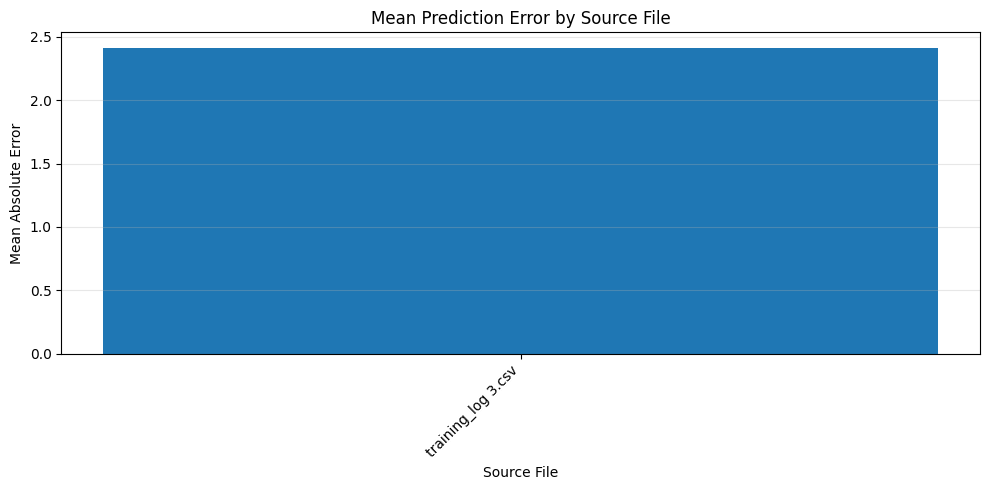

Source files with higher error may indicate difficult training-run conditions.


In [20]:
# ==========================================
# STEP 20: ERROR BY SOURCE FILE
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    source_error_summary["source_file"],
    source_error_summary["Mean_Absolute_Error"]
)

plt.xlabel("Source File")
plt.ylabel("Mean Absolute Error")
plt.title("Mean Prediction Error by Source File")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Source files with higher error may indicate difficult training-run conditions.")

In [21]:
# ==========================================
# STEP 21: ERROR VS INPUT FEATURES
# ==========================================

import pandas as pd
import numpy as np

# Use the last time step of each test sequence
last_step_features = X_test[:, -1, :]

error_feature_df = pd.DataFrame(
    last_step_features,
    columns=FEATURES
)

error_feature_df["Absolute_Error"] = error_df["Absolute_Error"].values

# Calculate correlation with absolute error
correlation = (
    error_feature_df
    .corr(numeric_only=True)["Absolute_Error"]
    .drop("Absolute_Error")
    .sort_values(ascending=False)
)

print("Correlation between input features and absolute prediction error:")
display(correlation.to_frame("Correlation").round(6))

# Save results
correlation.to_csv("/content/error_feature_correlation.csv")

print("\nSaved:")
print("/content/error_feature_correlation.csv")

Correlation between input features and absolute prediction error:


,Correlation
step,0.196033
epoch,0.195583
time_s,0.147244
disc_loss,0.109041



Saved:
/content/error_feature_correlation.csv


In [22]:
# ==========================================
# STEP 22: LIMITATION LIST
# ==========================================

limitations = [
    "The prediction target is gen_total, not SoH or RUL.",

    "The available data consists mainly of GAN training logs rather than "
    "direct image-quality ground-truth measurements.",

    "No verified physical cell IDs or degradation-stage labels are available "
    "in the current dataset.",

    "Sequences were constructed globally, so some sequences may cross "
    "source-file boundaries. A future clean revision should prevent this.",

    "source_file is treated only as a training-run/source identifier, "
    "not as a physical cell or degradation condition.",

    "Target-range groups are statistical ranges based on gen_total and "
    "should not be interpreted as verified degradation stages.",

    "Permutation feature importance indicates predictive dependence and "
    "does not establish causal importance.",

    "The current error analysis is primarily log-level and does not establish "
    "a direct relationship between prediction errors and visible underwater "
    "image-scene failures.",

    "Image-level enhancement metrics such as PSNR, SSIM, UIQM, or UCIQE "
    "are not available or verified in the current log dataset.",

    "Mentor corrections and final approval are still pending."
]

limitation_df = pd.DataFrame({
    "Limitation_No": range(1, len(limitations) + 1),
    "Limitation": limitations
})

display(limitation_df)

# Save limitation list
limitation_df.to_csv(
    "/content/limitation_list.csv",
    index=False
)

print("\nLimitation list saved successfully:")
print("/content/limitation_list.csv")

,Limitation_No,Limitation
0,1,"The prediction target is gen_total, not SoH or..."
1,2,The available data consists mainly of GAN trai...
2,3,No verified physical cell IDs or degradation-s...
3,4,"Sequences were constructed globally, so some s..."
4,5,source_file is treated only as a training-run/...
5,6,Target-range groups are statistical ranges bas...
6,7,Permutation feature importance indicates predi...
7,8,The current error analysis is primarily log-le...
8,9,"Image-level enhancement metrics such as PSNR, ..."
9,10,Mentor corrections and final approval are stil...



Limitation list saved successfully:
/content/limitation_list.csv


In [23]:
# ==========================================
# STEP 23: COMPLETE ERROR ANALYSIS REPORT
# ==========================================

report_lines = []

report_lines.append("DETAILED ERROR / FAILURE ANALYSIS REPORT")
report_lines.append("=" * 50)
report_lines.append("")

# Overall metrics
report_lines.append("1. OVERALL TEST PERFORMANCE")
report_lines.append("-" * 35)
report_lines.append(f"MAE: {mae:.6f}")
report_lines.append(f"RMSE: {rmse:.6f}")
report_lines.append(f"MAPE: {mape:.6f}")
report_lines.append(f"R2: {r2:.6f}")
report_lines.append(
    f"95th Percentile Absolute Error: "
    f"{np.percentile(error_df['Absolute_Error'], 95):.6f}"
)
report_lines.append(
    f"Maximum Absolute Error: "
    f"{error_df['Absolute_Error'].max():.6f}"
)
report_lines.append("")

# Worst cases
report_lines.append("2. WORST PREDICTION CASES")
report_lines.append("-" * 35)

worst10 = error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

for idx, row in worst10.iterrows():
    report_lines.append(
        f"Test Index {idx}: "
        f"Actual={row['Actual']:.6f}, "
        f"Predicted={row['Predicted']:.6f}, "
        f"Absolute Error={row['Absolute_Error']:.6f}"
    )

report_lines.append("")

# Source analysis
report_lines.append("3. SOURCE-FILE ERROR ANALYSIS")
report_lines.append("-" * 35)

for _, row in source_error_summary.iterrows():
    report_lines.append(
        f"{row['source_file']}: "
        f"Samples={int(row['Samples'])}, "
        f"Mean Absolute Error={row['Mean_Absolute_Error']:.6f}, "
        f"Maximum Error={row['Maximum_Error']:.6f}"
    )

report_lines.append("")

# Feature importance
report_lines.append("4. PERMUTATION FEATURE IMPORTANCE")
report_lines.append("-" * 35)

for _, row in feature_importance_df.iterrows():
    report_lines.append(
        f"{row['Feature']}: "
        f"MAE Increase={row['MAE_Increase']:.6f}"
    )

report_lines.append("")

# Limitations
report_lines.append("5. LIMITATIONS")
report_lines.append("-" * 35)

for i, limitation in enumerate(limitations, 1):
    report_lines.append(f"{i}. {limitation}")

report_lines.append("")
report_lines.append("6. CONCLUSION")
report_lines.append("-" * 35)
report_lines.append(
    "The error analysis identifies the largest prediction errors, "
    "source-run variation, target-range behaviour, and feature dependence. "
    "The results should be interpreted within the documented dataset and "
    "methodological limitations."
)

# Save report
report_path = "/content/detailed_error_analysis_report.txt"

with open(report_path, "w") as f:
    f.write("\n".join(report_lines))

print("Detailed error-analysis report created successfully.")
print(report_path)

# Display report
print("\n" + "\n".join(report_lines))

Detailed error-analysis report created successfully.
/content/detailed_error_analysis_report.txt

DETAILED ERROR / FAILURE ANALYSIS REPORT

1. OVERALL TEST PERFORMANCE
-----------------------------------
MAE: 2.412714
RMSE: 3.164585
MAPE: 18.652487
R2: 0.132594
95th Percentile Absolute Error: 6.309841
Maximum Absolute Error: 15.637934

2. WORST PREDICTION CASES
-----------------------------------
Test Index 3491: Actual=24.754225, Predicted=9.116291, Absolute Error=15.637934
Test Index 3735: Actual=22.243809, Predicted=8.999892, Absolute Error=13.243917
Test Index 3583: Actual=16.444281, Predicted=3.249277, Absolute Error=13.195004
Test Index 3221: Actual=17.810534, Predicted=5.186536, Absolute Error=12.623998
Test Index 3345: Actual=20.322777, Predicted=8.386772, Absolute Error=11.936005
Test Index 2994: Actual=19.913315, Predicted=8.002224, Absolute Error=11.911091
Test Index 3008: Actual=20.543194, Predicted=9.039268, Absolute Error=11.503925
Test Index 2705: Actual=20.818750, Predi

In [24]:
# ==========================================
# STEP 24: PACKAGE ERROR ANALYSIS ARTIFACTS
# ==========================================

import zipfile
import os

artifact_files = [
    "/content/worst_predictions.csv",
    "/content/source_error_summary.csv",
    "/content/target_range_error_summary.csv",
    "/content/feature_importance.csv",
    "/content/error_feature_correlation.csv",
    "/content/limitation_list.csv",
    "/content/detailed_error_analysis_report.txt",
    "/content/actual_vs_predicted.png"
]

zip_path = "/content/Detailed_Error_Failure_Analysis_Artifacts.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in artifact_files:
        if os.path.exists(file_path):
            zipf.write(
                file_path,
                arcname=os.path.basename(file_path)
            )
            print("Added:", os.path.basename(file_path))
        else:
            print("Not found:", file_path)

print("\n========================================")
print("ERROR ANALYSIS PACKAGE CREATED")
print("========================================")
print(zip_path)

Added: worst_predictions.csv
Added: source_error_summary.csv
Added: target_range_error_summary.csv
Added: feature_importance.csv
Added: error_feature_correlation.csv
Added: limitation_list.csv
Added: detailed_error_analysis_report.txt
Not found: /content/actual_vs_predicted.png

ERROR ANALYSIS PACKAGE CREATED
/content/Detailed_Error_Failure_Analysis_Artifacts.zip


In [25]:
# ==========================================
# STEP 25: DOWNLOAD FINAL ARTIFACTS
# ==========================================

from google.colab import files

print("Final Error / Failure Analysis package:")
print("/content/Detailed_Error_Failure_Analysis_Artifacts.zip")

files.download(
    "/content/Detailed_Error_Failure_Analysis_Artifacts.zip"
)

Final Error / Failure Analysis package:
/content/Detailed_Error_Failure_Analysis_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>